#In this .ipynb file we do chunking<br>
Chunking is the process of dividing a large data 
into smaller meaningfull units called chunk

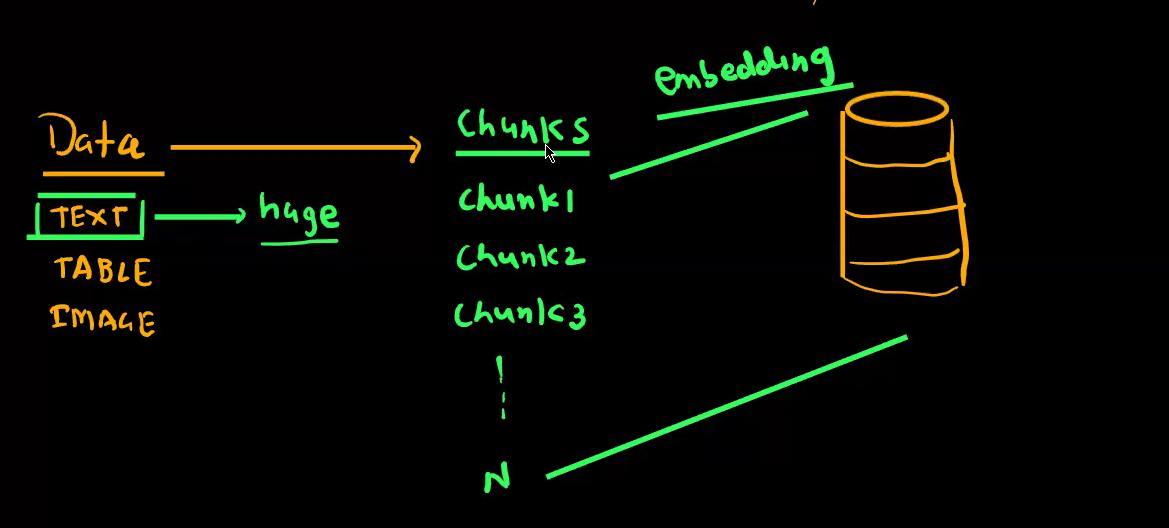


In [4]:
from __future__ import annotations
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter,
    MarkdownHeaderTextSplitter,
    TokenTextSplitter,
)

1. Sample Document<br>
The sample document intentionally contains multiple topics and Markdown headings.<br>
This makes it useful for comparing basic, structure-aware, and semantic chunking.

In [10]:
from pypdf import PdfReader
reader=PdfReader(r"D:\GEN AI BASICS\RAG\Vector-database\Data\llama2-research-paper.pdf")
page_text=[]
for page_number,page in enumerate(reader.pages,start=1):
    text=page.extract_text() or ""
    if text.strip():
        page_text.append(text)
    print(f"page_number: {page_number}, text length: {len(text)}")


page_number: 1, text length: 1892
page_number: 2, text length: 2452
page_number: 3, text length: 3688
page_number: 4, text length: 2508
page_number: 5, text length: 2778
page_number: 6, text length: 2116
page_number: 7, text length: 3792
page_number: 8, text length: 3145
page_number: 9, text length: 4016
page_number: 10, text length: 4970
page_number: 11, text length: 4150
page_number: 12, text length: 3722
page_number: 13, text length: 3599
page_number: 14, text length: 2569
page_number: 15, text length: 4253
page_number: 16, text length: 3185
page_number: 17, text length: 4583
page_number: 18, text length: 3304
page_number: 19, text length: 2677
page_number: 20, text length: 4867
page_number: 21, text length: 2931
page_number: 22, text length: 3630
page_number: 23, text length: 3542
page_number: 24, text length: 4882
page_number: 25, text length: 2363
page_number: 26, text length: 3332
page_number: 27, text length: 4053
page_number: 28, text length: 3226
page_number: 29, text length:

In [11]:
document_text = "\n\n".join(page_text)

In [ ]:
#CharacterTextSplitter->Split the text at every blank line (double newline)
character_splitter = CharacterTextSplitter(chunk_size=300, 
                                           chunk_overlap=50,
                                           length_function=len, 
                                           separator="\n\n"
)
character_chunks = character_splitter.split_text(document_text)

Created a chunk of size 1892, which is longer than the specified 300
Created a chunk of size 2452, which is longer than the specified 300
Created a chunk of size 3688, which is longer than the specified 300
Created a chunk of size 2508, which is longer than the specified 300
Created a chunk of size 2778, which is longer than the specified 300
Created a chunk of size 2116, which is longer than the specified 300
Created a chunk of size 3792, which is longer than the specified 300
Created a chunk of size 3145, which is longer than the specified 300
Created a chunk of size 4016, which is longer than the specified 300
Created a chunk of size 4970, which is longer than the specified 300
Created a chunk of size 4150, which is longer than the specified 300
Created a chunk of size 3722, which is longer than the specified 300
Created a chunk of size 3599, which is longer than the specified 300
Created a chunk of size 2569, which is longer than the specified 300
Created a chunk of size 4253, whic

In [16]:
recursive_splitter = RecursiveCharacterTextSplitter(chunk_size=300,
                                                   chunk_overlap=50,
                                                   length_function=len, 
                                                   separators=["\n\n", "\n", " ", ""]
)
recursive_chunks = recursive_splitter.split_text(document_text)
print(f"Number of chunks created by RecursiveCharacterTextSplitter: {len(recursive_chunks)}")

Number of chunks created by RecursiveCharacterTextSplitter: 1107


In [17]:
token_splitter = TokenTextSplitter(chunk_size=80,
                                   encoding_name="cl100k_base",
                                   chunk_overlap=15,
                                      length_function=len
)
token_chunks = token_splitter.split_text(document_text)

SEMANTIC CHUNKING

In [ ]:
import nltk
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Download tokenizer once
nltk.download("punkt")

#########################################################
# Step 1 : Split document into sentences
#########################################################

def split_into_sentences(text):
    return nltk.sent_tokenize(text)

#########################################################
# Step 2 : Create sentence windows
#########################################################

def create_sentence_windows(sentences, window_size=3):
    windows = []

    for i in range(len(sentences)):
        start = max(0, i - window_size // 2)
        end = min(len(sentences), i + window_size // 2 + 1)

        window = " ".join(sentences[start:end])
        windows.append(window)

    return windows

#########################################################
# Step 3 : Create embeddings
#########################################################

def create_local_embeddings(windows, model_name="sentence-transformers/all-MiniLM-L6-v2"):

    model = SentenceTransformer(model_name)

    embeddings = model.encode(
        windows,
        convert_to_numpy=True,
        show_progress_bar=True
    )

    return embeddings

#########################################################
# Step 4 : Compute similarities
#########################################################

def calculate_similarities(embeddings):

    similarities = []

    for i in range(len(embeddings)-1):

        sim = cosine_similarity(
            [embeddings[i]],
            [embeddings[i+1]]
        )[0][0]

        similarities.append(sim)

    return similarities

#########################################################
# Step 5 : Find topic boundaries
#########################################################

def find_boundaries(similarities, threshold=0.75):

    boundaries = []

    for i, sim in enumerate(similarities):

        if sim < threshold:
            boundaries.append(i+1)

    return boundaries

#########################################################
# Step 6 : Create semantic chunks
#########################################################

def create_chunks(sentences, boundaries):

    chunks = []

    start = 0

    for boundary in boundaries:

        chunk = " ".join(sentences[start:boundary])

        chunks.append(chunk)

        start = boundary

    chunks.append(" ".join(sentences[start:]))

    return chunks

#########################################################
# Complete Pipeline
#########################################################

def semantic_chunking(text):

    print("Splitting into sentences...")

    sentences = split_into_sentences(text)

    print("Creating sentence windows...")

    windows = create_sentence_windows(sentences)

    print("Generating embeddings...")

    embeddings = create_local_embeddings(windows)

    print("Calculating similarities...")

    similarities = calculate_similarities(embeddings)

    print("Finding topic boundaries...")

    boundaries = find_boundaries(similarities)

    print("Creating semantic chunks...")

    chunks = create_chunks(sentences, boundaries)

    return chunks  


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vansh_hxqeh4o\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
